In [1]:
# ============================================================
# CELL 1: Import libraries (xgboost and ipywidgets are already
# pre-installed on Kaggle, so no pip install needed)
# ============================================================

# Core data handling
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Saving models
import joblib

# Interactive widgets (Phase 6)
import ipywidgets as widgets
from IPython.display import display, clear_output

# Silence noisy warnings so your output stays clean
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


In [3]:
# ============================================================
# CELL 2: Load all data, including the live 2026-27 season
# (built from the full fixture list + results file combined)
# ============================================================

DATA_DIR = "/kaggle/input/datasets/abdelrahmanmoamen91/pl-predictor-data"

pl_2023_24 = pd.read_csv(f"{DATA_DIR}/epl_2324.csv")
pl_2024_25 = pd.read_csv(f"{DATA_DIR}/epl_2425.csv")
pl_2025_26 = pd.read_csv(f"{DATA_DIR}/epl_2526.csv")
champ_2025_26 = pd.read_csv(f"{DATA_DIR}/EFL_Championship.csv")

KEEP_COLS = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR",
             "HST", "AST", "HC", "AC"]

def clean_columns(df):
    cols_present = [c for c in KEEP_COLS if c in df.columns]
    return df[cols_present].copy()

pl_2023_24 = clean_columns(pl_2023_24)
pl_2024_25 = clean_columns(pl_2024_25)
pl_2025_26 = clean_columns(pl_2025_26)
champ_2025_26 = clean_columns(champ_2025_26)

# --- Build the 2026-27 season from the full fixture list ---
fixtures_raw = pd.read_csv(f"{DATA_DIR}/epl_2627_fixtures.csv")

NAME_FIX = {"Man Utd": "Man United", "Spurs": "Tottenham"}
fixtures_raw["Home Team"] = fixtures_raw["Home Team"].replace(NAME_FIX)
fixtures_raw["Away Team"] = fixtures_raw["Away Team"].replace(NAME_FIX)

fixtures_raw = fixtures_raw.rename(columns={"Home Team": "HomeTeam", "Away Team": "AwayTeam"})

fixtures_raw["Date"] = pd.to_datetime(
    fixtures_raw["Date"].str.split(" ").str[0], dayfirst=True, errors="coerce"
)

def parse_result(r):
    if pd.isna(r) or "-" not in str(r):
        return pd.Series({"FTHG": np.nan, "FTAG": np.nan})
    parts = str(r).split("-")
    try:
        return pd.Series({"FTHG": int(parts[0].strip()), "FTAG": int(parts[1].strip())})
    except ValueError:
        return pd.Series({"FTHG": np.nan, "FTAG": np.nan})

goals = fixtures_raw["Result"].apply(parse_result)
fixtures_raw = pd.concat([fixtures_raw, goals], axis=1)

def calc_ftr(row):
    if pd.isna(row["FTHG"]) or pd.isna(row["FTAG"]):
        return np.nan
    if row["FTHG"] > row["FTAG"]:
        return "H"
    elif row["FTHG"] < row["FTAG"]:
        return "A"
    else:
        return "D"

fixtures_raw["FTR"] = fixtures_raw.apply(calc_ftr, axis=1)

pl_2026_27 = fixtures_raw[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]].copy()

# Bring in shot/corner stats for already-played matches from epl_2627.csv
stats_source = pd.read_csv(f"{DATA_DIR}/epl_2627.csv")
stats_source = clean_columns(stats_source)
stats_source["Date"] = pd.to_datetime(stats_source["Date"], dayfirst=True, errors="coerce")

pl_2026_27 = pl_2026_27.merge(
    stats_source[["Date", "HomeTeam", "AwayTeam", "HST", "AST", "HC", "AC"]],
    on=["Date", "HomeTeam", "AwayTeam"], how="left"
)

# Tag seasons/leagues
pl_2023_24["Season"] = "2023-24"
pl_2024_25["Season"] = "2024-25"
pl_2025_26["Season"] = "2025-26"
pl_2026_27["Season"] = "2026-27"
champ_2025_26["Season"] = "2025-26"

pl_2023_24["League"] = "PL"
pl_2024_25["League"] = "PL"
pl_2025_26["League"] = "PL"
pl_2026_27["League"] = "PL"
champ_2025_26["League"] = "Championship"

for df in [pl_2023_24, pl_2024_25, pl_2025_26, champ_2025_26]:
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

pl_all = pd.concat([pl_2023_24, pl_2024_25, pl_2025_26, pl_2026_27], ignore_index=True)
pl_all = pl_all.sort_values("Date").reset_index(drop=True)

print(f"Total PL matches loaded: {len(pl_all)}")
print(f"Championship matches loaded: {len(champ_2025_26)}")
print(f"\n2026-27 season: {len(pl_2026_27)} total matches")
print(f"  Played so far: {pl_2026_27['FTR'].notna().sum()}")
print(f"  Still to play:  {pl_2026_27['FTR'].isna().sum()}")
pl_2026_27.head(10)

Total PL matches loaded: 1520
Championship matches loaded: 552

2026-27 season: 380 total matches
  Played so far: 50
  Still to play:  330


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HST,AST,HC,AC,Season,League
0,2026-08-21,Arsenal,Coventry,3.0,0.0,H,6.0,1.0,8.0,2.0,2026-27,PL
1,2026-08-22,Hull,Man United,2.0,0.0,H,4.0,5.0,1.0,6.0,2026-27,PL
2,2026-08-22,Everton,Crystal Palace,2.0,0.0,H,5.0,4.0,4.0,0.0,2026-27,PL
3,2026-08-22,Ipswich,Sunderland,2.0,1.0,H,3.0,4.0,3.0,5.0,2026-27,PL
4,2026-08-22,Nott'm Forest,Leeds,0.0,1.0,A,2.0,3.0,3.0,2.0,2026-27,PL
5,2026-08-22,Brentford,Tottenham,3.0,0.0,H,8.0,4.0,7.0,3.0,2026-27,PL
6,2026-08-23,Brighton,Aston Villa,4.0,0.0,H,6.0,0.0,5.0,2.0,2026-27,PL
7,2026-08-23,Man City,Bournemouth,2.0,1.0,H,6.0,4.0,8.0,3.0,2026-27,PL
8,2026-08-23,Newcastle,Liverpool,2.0,2.0,D,4.0,7.0,2.0,6.0,2026-27,PL
9,2026-08-24,Fulham,Chelsea,2.0,3.0,A,6.0,6.0,6.0,4.0,2026-27,PL


In [4]:
# ============================================================
# CELL 3: Separate "played" matches (have a result) from
# "unplayed" fixtures (genuinely upcoming 2026-27 matches)
# ============================================================

played_matches = pl_all[pl_all["FTR"].notna()].copy()
unplayed_fixtures = pl_all[pl_all["FTR"].isna()].copy()

print(f"Played matches (used for training): {len(played_matches)}")
print(f"Unplayed fixtures (used for simulation): {len(unplayed_fixtures)}")

Played matches (used for training): 1190
Unplayed fixtures (used for simulation): 330


In [5]:
# Check the 2025-26 file specifically for played vs unplayed matches
print(f"Total rows in epl_2526.csv: {len(pl_2025_26)}")
print(f"Rows with a result (FTR filled): {pl_2025_26['FTR'].notna().sum()}")
print(f"Rows with no result (FTR blank): {pl_2025_26['FTR'].isna().sum()}")
print()
print("Date range in this file:")
print(f"  Earliest: {pl_2025_26['Date'].min()}")
print(f"  Latest:   {pl_2025_26['Date'].max()}")

Total rows in epl_2526.csv: 380
Rows with a result (FTR filled): 380
Rows with no result (FTR blank): 0

Date range in this file:
  Earliest: 2025-08-15 00:00:00
  Latest:   2026-05-24 00:00:00


In [6]:
# ============================================================
# CELL 4: Build rolling 5-match "form" stats for every team
# ============================================================

def build_team_match_log(df):
    home = df[["Date", "HomeTeam", "FTHG", "FTAG", "HST", "AST", "HC", "AC", "FTR"]].copy()
    home = home.rename(columns={
        "HomeTeam": "Team", "FTHG": "GoalsFor", "FTAG": "GoalsAgainst",
        "HST": "ShotsOnTarget", "AST": "ShotsOnTargetAgainst",
        "HC": "Corners", "AC": "CornersAgainst"
    })
    home["Venue"] = "Home"
    home["Win"] = (home["FTR"] == "H").astype(int)

    away = df[["Date", "AwayTeam", "FTAG", "FTHG", "AST", "HST", "AC", "HC", "FTR"]].copy()
    away = away.rename(columns={
        "AwayTeam": "Team", "FTAG": "GoalsFor", "FTHG": "GoalsAgainst",
        "AST": "ShotsOnTarget", "HST": "ShotsOnTargetAgainst",
        "AC": "Corners", "HC": "CornersAgainst"
    })
    away["Venue"] = "Away"
    away["Win"] = (away["FTR"] == "A").astype(int)

    log = pd.concat([home, away], ignore_index=True).sort_values(["Team", "Date"])
    return log.reset_index(drop=True)

team_log = build_team_match_log(played_matches)

ROLL_WINDOW = 5
roll_cols = ["GoalsFor", "GoalsAgainst", "ShotsOnTarget", "ShotsOnTargetAgainst",
             "Corners", "CornersAgainst", "Win"]

for col in roll_cols:
    team_log[f"Roll_{col}"] = (
        team_log.groupby("Team")[col]
        .transform(lambda s: s.shift(1).rolling(ROLL_WINDOW, min_periods=1).mean())
    )

print("Sample of rolling form features:")
team_log[["Team", "Date", "Roll_GoalsFor", "Roll_GoalsAgainst", "Roll_Win"]].tail(10)

Sample of rolling form features:


,Team,Date,Roll_GoalsFor,Roll_GoalsAgainst,Roll_Win
2370,Wolves,2026-02-27,0.6,1.6,0.0
2371,Wolves,2026-03-03,1.0,1.2,0.2
2372,Wolves,2026-03-16,1.2,0.8,0.4
2373,Wolves,2026-04-10,1.6,1.2,0.4
2374,Wolves,2026-04-18,1.2,1.6,0.4
2375,Wolves,2026-04-25,1.2,2.0,0.4
2376,Wolves,2026-05-02,0.8,2.2,0.2
2377,Wolves,2026-05-09,0.6,2.2,0.0
2378,Wolves,2026-05-17,0.2,2.4,0.0
2379,Wolves,2026-05-24,0.4,1.8,0.0


In [7]:
# ============================================================
# CELL 5: Handle promoted teams with no/limited PL history
# ============================================================

ATTACK_MULTIPLIER = 0.65
DEFENSE_RISK_MULTIPLIER = 1.35

ATTACK_COLS = ["Roll_GoalsFor", "Roll_ShotsOnTarget", "Roll_Corners", "Roll_Win"]
DEFENSE_RISK_COLS = ["Roll_GoalsAgainst", "Roll_ShotsOnTargetAgainst", "Roll_CornersAgainst"]

champ_log = build_team_match_log(champ_2025_26)
for col in roll_cols:
    champ_log[f"Roll_{col}"] = (
        champ_log.groupby("Team")[col]
        .transform(lambda s: s.shift(1).rolling(ROLL_WINDOW, min_periods=1).mean())
    )

def get_latest_form(log_df, team):
    team_rows = log_df[log_df["Team"] == team].sort_values("Date")
    if len(team_rows) == 0:
        return None
    return team_rows.iloc[-1]

current_pl_teams = pd.unique(
    pl_2026_27[["HomeTeam", "AwayTeam"]].values.ravel()
)

pl_form_latest = (
    team_log.sort_values("Date")
    .groupby("Team")
    .tail(1)
    .set_index("Team")
)
baseline_25th = pl_form_latest[[f"Roll_{c}" for c in roll_cols]].quantile(0.25)

def get_team_form_with_fallback(team, log_df=team_log):
    pl_row = get_latest_form(log_df, team)
    if pl_row is not None and not pd.isna(pl_row["Roll_GoalsFor"]):
        return pl_row[[f"Roll_{c}" for c in roll_cols]], "PL_HISTORY"

    champ_row = get_latest_form(champ_log, team)
    if champ_row is not None and not pd.isna(champ_row["Roll_GoalsFor"]):
        adjusted = champ_row[[f"Roll_{c}" for c in roll_cols]].copy()
        for c in ATTACK_COLS:
            adjusted[c] = adjusted[c] * ATTACK_MULTIPLIER
        for c in DEFENSE_RISK_COLS:
            adjusted[c] = adjusted[c] * DEFENSE_RISK_MULTIPLIER
        return adjusted, "CHAMPIONSHIP_ADJUSTED"

    return baseline_25th.copy(), "BASELINE_FALLBACK"

print("Data source used per team:")
for team in sorted(current_pl_teams):
    _, source = get_team_form_with_fallback(team)
    print(f"  {team:25s} -> {source}")

Data source used per team:
  Arsenal                   -> PL_HISTORY
  Aston Villa               -> PL_HISTORY
  Bournemouth               -> PL_HISTORY
  Brentford                 -> PL_HISTORY
  Brighton                  -> PL_HISTORY
  Chelsea                   -> PL_HISTORY
  Coventry                  -> PL_HISTORY
  Crystal Palace            -> PL_HISTORY
  Everton                   -> PL_HISTORY
  Fulham                    -> PL_HISTORY
  Hull                      -> PL_HISTORY
  Ipswich                   -> PL_HISTORY
  Leeds                     -> PL_HISTORY
  Liverpool                 -> PL_HISTORY
  Man City                  -> PL_HISTORY
  Man United                -> PL_HISTORY
  Newcastle                 -> PL_HISTORY
  Nott'm Forest             -> PL_HISTORY
  Sunderland                -> PL_HISTORY
  Tottenham                 -> PL_HISTORY


In [8]:
# ============================================================
# NEW CELL: Last-season final standing (points-per-game) feature
# ============================================================

# Maps each season to the season immediately before it
PREV_SEASON_MAP = {
    "2024-25": "2023-24",
    "2025-26": "2024-25",
    "2026-27": "2025-26",
}

def compute_season_ppg(season_label):
    """Returns {team: points-per-game} for every team in that PL season."""
    season_matches = pl_all[(pl_all["Season"] == season_label) & (pl_all["FTR"].notna())]
    teams = pd.unique(season_matches[["HomeTeam", "AwayTeam"]].values.ravel())
    ppg = {}
    for team in teams:
        home_games = season_matches[season_matches["HomeTeam"] == team]
        away_games = season_matches[season_matches["AwayTeam"] == team]
        games = len(home_games) + len(away_games)
        points = 0
        points += ((home_games["FTHG"] > home_games["FTAG"]) * 3).sum()
        points += (home_games["FTHG"] == home_games["FTAG"]).sum()
        points += ((away_games["FTAG"] > away_games["FTHG"]) * 3).sum()
        points += (away_games["FTAG"] == away_games["FTHG"]).sum()
        ppg[team] = points / games if games > 0 else np.nan
    return ppg

# Pre-calculate points-per-game for every season we have
season_ppg = {s: compute_season_ppg(s) for s in ["2023-24", "2024-25", "2025-26", "2026-27"]}

def get_last_season_ppg(team, current_season):
    """
    Looks up a team's PPG from the season before current_season.
    If the team wasn't in the PL last season (promoted team),
    falls back to the bottom-25th-percentile PPG of that season —
    a reasonable 'weak newcomer' estimate.
    """
    prev_season = PREV_SEASON_MAP.get(current_season)
    if prev_season is None:
        return 1.3  # no prior season in our data (e.g. very first season) — neutral guess

    ppg_dict = season_ppg.get(prev_season, {})
    if team in ppg_dict and not pd.isna(ppg_dict[team]):
        return ppg_dict[team]

    values = [v for v in ppg_dict.values() if not pd.isna(v)]
    return np.percentile(values, 25) if values else 1.0

print("✅ Last-season PPG lookup ready.")
print("\nSample — 2026-27 teams' last-season (2025-26) PPG:")
for team in sorted(current_pl_teams):
    print(f"  {team:20s} -> {get_last_season_ppg(team, '2026-27'):.2f}")

✅ Last-season PPG lookup ready.

Sample — 2026-27 teams' last-season (2025-26) PPG:
  Arsenal              -> 2.24
  Aston Villa          -> 1.71
  Bournemouth          -> 1.50
  Brentford            -> 1.39
  Brighton             -> 1.39
  Chelsea              -> 1.37
  Coventry             -> 1.18
  Crystal Palace       -> 1.18
  Everton              -> 1.29
  Fulham               -> 1.37
  Hull                 -> 1.18
  Ipswich              -> 1.18
  Leeds                -> 1.24
  Liverpool            -> 1.58
  Man City             -> 2.05
  Man United           -> 1.87
  Newcastle            -> 1.29
  Nott'm Forest        -> 1.16
  Sunderland           -> 1.42
  Tottenham            -> 1.08


In [9]:
# ============================================================
# NEW CELL: Blended team-quality feature — combines last-season
# PPG with current-season PPG-so-far, weighted by how many games
# have been played this season (early season trusts last year more,
# later season trusts this year's real results more)
# ============================================================

DECAY_GAMES = 15  # by this many games played, we fully trust current-season form

def get_current_season_ppg_so_far(team, date, season):
    """
    Returns (games_played, ppg_so_far) for this team, THIS season,
    using only matches strictly before `date` — no future leakage.
    """
    season_matches = pl_all[
        (pl_all["Season"] == season) &
        (pl_all["Date"] < date) &
        (pl_all["FTR"].notna()) &
        ((pl_all["HomeTeam"] == team) | (pl_all["AwayTeam"] == team))
    ]
    games_played = len(season_matches)
    if games_played == 0:
        return 0, np.nan

    points = 0
    for _, m in season_matches.iterrows():
        if m["HomeTeam"] == team:
            if m["FTHG"] > m["FTAG"]: points += 3
            elif m["FTHG"] == m["FTAG"]: points += 1
        else:
            if m["FTAG"] > m["FTHG"]: points += 3
            elif m["FTAG"] == m["FTHG"]: points += 1

    return games_played, points / games_played

def get_blended_ppg(team, date, season):
    """
    Blends last-season PPG with current-season PPG-so-far.
    Weight on current-season grows linearly from 0 to 1 over
    the first DECAY_GAMES games, then stays at 1.
    """
    games_played, current_ppg = get_current_season_ppg_so_far(team, date, season)
    last_season_ppg = get_last_season_ppg(team, season)

    if games_played == 0 or pd.isna(current_ppg):
        return last_season_ppg  # no games yet this season — pure last-season trust

    weight_current = min(games_played / DECAY_GAMES, 1.0)
    weight_last = 1 - weight_current

    return (current_ppg * weight_current) + (last_season_ppg * weight_last)

print("✅ Blended PPG function ready.")

# Quick sanity check — Aston Villa's blended quality right now (today, 2026-27)
today = pl_2026_27["Date"].max()  # latest date in our data as a proxy for "now"
games, current_ppg = get_current_season_ppg_so_far("Aston Villa", pd.Timestamp("2026-09-20"), "2026-27")
blended = get_blended_ppg("Aston Villa", pd.Timestamp("2026-09-20"), "2026-27")
print(f"\nAston Villa — games played: {games}, current-season PPG: {current_ppg:.2f}")
print(f"Last-season PPG: {get_last_season_ppg('Aston Villa', '2026-27'):.2f}")
print(f"Blended PPG (weight on current: {min(games/DECAY_GAMES,1):.2f}): {blended:.2f}")

✅ Blended PPG function ready.

Aston Villa — games played: 5, current-season PPG: 0.80
Last-season PPG: 1.71
Blended PPG (weight on current: 0.33): 1.41


In [10]:
# ============================================================
# CELL 6 (v4): Assemble features — LastSeasonPPG + new QualityGap
# feature to help the model better recognize close matchups (draws)
# ============================================================

def build_feature_row(row, log_df):
    date = row["Date"]
    home, away = row["HomeTeam"], row["AwayTeam"]
    season = row["Season"]

    def form_before_date(team):
        history = log_df[(log_df["Team"] == team) & (log_df["Date"] < date)]
        if len(history) == 0:
            return baseline_25th.copy()
        return history.sort_values("Date").iloc[-1][[f"Roll_{c}" for c in roll_cols]]

    home_form = form_before_date(home)
    away_form = form_before_date(away)

    feature_row = {}
    for c in roll_cols:
        feature_row[f"Home_{c}"] = home_form[f"Roll_{c}"]
        feature_row[f"Away_{c}"] = away_form[f"Roll_{c}"]

    home_ppg = get_last_season_ppg(home, season)
    away_ppg = get_last_season_ppg(away, season)
    feature_row["Home_LastSeasonPPG"] = home_ppg
    feature_row["Away_LastSeasonPPG"] = away_ppg
    feature_row["QualityGap"] = abs(home_ppg - away_ppg)  # NEW: small gap = evenly matched

    return pd.Series(feature_row)

print("Building features for every historical match (~45-90 seconds)...")
feature_rows = played_matches.apply(lambda r: build_feature_row(r, team_log), axis=1)
model_data = pd.concat([played_matches.reset_index(drop=True), feature_rows], axis=1)

model_data["Target"] = model_data["FTR"].map({"H": 1, "D": 0, "A": 2})

model_data = model_data.dropna(subset=[f"Home_{c}" for c in roll_cols] +
                                       [f"Away_{c}" for c in roll_cols] +
                                       ["Home_LastSeasonPPG", "Away_LastSeasonPPG", "QualityGap", "Target"])

FEATURE_COLS = [f"Home_{c}" for c in roll_cols] + [f"Away_{c}" for c in roll_cols] + \
               ["Home_LastSeasonPPG", "Away_LastSeasonPPG", "QualityGap"]

print(f"Final training dataset shape: {model_data.shape}")
model_data[FEATURE_COLS + ["Target"]].tail()

Building features for every historical match (~45-90 seconds)...
Final training dataset shape: (1173, 30)


,Home_GoalsFor,Home_GoalsAgainst,Home_ShotsOnTarget,Home_ShotsOnTargetAgainst,Home_Corners,Home_CornersAgainst,Home_Win,Away_GoalsFor,Away_GoalsAgainst,Away_ShotsOnTarget,Away_ShotsOnTargetAgainst,Away_Corners,Away_CornersAgainst,Away_Win,Home_LastSeasonPPG,Away_LastSeasonPPG,QualityGap,Target
1185,1.2,1.4,5.0,4.2,4.0,4.2,0.2,1.0,2.6,3.8,6.2,3.4,3.6,0.2,1.289474,1.177632,0.111842,1
1186,1.2,1.4,4.0,5.0,5.2,6.2,0.0,1.8,1.8,6.2,4.6,7.0,3.4,0.2,1.500000,1.578947,0.078947,2
1187,0.8,1.0,2.8,5.8,4.8,6.0,0.4,1.4,2.4,3.6,6.0,2.0,6.0,0.2,1.236842,1.184211,0.052632,0
1188,1.8,1.0,5.4,3.0,6.6,4.2,0.6,1.6,1.0,3.6,2.0,4.0,4.2,0.6,2.052632,1.421053,0.631579,1
1189,1.4,1.6,4.6,4.0,5.8,3.4,0.2,2.6,1.6,6.8,4.2,5.4,3.0,0.6,1.368421,1.868421,0.500000,0


In [11]:
model_data[FEATURE_COLS + ["Target"]].iloc[200:205]

,Home_GoalsFor,Home_GoalsAgainst,Home_ShotsOnTarget,Home_ShotsOnTargetAgainst,Home_Corners,Home_CornersAgainst,Home_Win,Away_GoalsFor,Away_GoalsAgainst,Away_ShotsOnTarget,Away_ShotsOnTargetAgainst,Away_Corners,Away_CornersAgainst,Away_Win,Target
211,1.6,1.6,3.2,5.8,4.2,5.8,0.4,0.8,1.2,5.4,2.8,6.4,3.2,0.2,2
212,2.0,2.2,4.2,6.2,5.2,5.8,0.4,1.2,1.2,7.0,4.0,3.6,4.4,0.2,1
213,1.8,1.0,6.0,3.0,5.0,4.6,0.6,1.0,1.6,2.4,7.8,4.2,6.6,0.2,1
214,2.6,1.4,6.6,5.0,4.0,8.0,0.8,0.8,2.4,3.4,5.4,5.2,6.2,0.0,1
215,1.8,0.8,7.6,2.0,6.4,3.6,0.6,1.6,1.4,5.4,4.6,5.4,6.0,0.6,1


In [11]:
# ============================================================
# CELL 7: Time-based split
# ============================================================

model_data = model_data.sort_values("Date").reset_index(drop=True)
split_idx = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_idx]
test_data = model_data.iloc[split_idx:]

X_train, y_train = train_data[FEATURE_COLS], train_data["Target"]
X_test, y_test = test_data[FEATURE_COLS], test_data["Target"]

print(f"Training on {len(X_train)} matches (up to {train_data['Date'].max().date()})")
print(f"Testing on {len(X_test)} matches (from {test_data['Date'].min().date()} onward)")

Training on 938 matches (up to 2026-01-03)
Testing on 235 matches (from 2026-01-04 onward)


In [12]:
# ============================================================
# CELL 8: Train models, with sample weighting to help the
# model pay more attention to draws during training
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=6, random_state=42, class_weight="balanced"
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

# Give draws (class 0) extra weight during training
sample_weights = np.where(y_train == 0, 2.0, 1.0)

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"Random Forest accuracy: {rf_acc:.3f}")
print(f"XGBoost accuracy:       {xgb_acc:.3f}")
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_preds, target_names=["Draw", "Home Win", "Away Win"]))

Random Forest accuracy: 0.455
XGBoost accuracy:       0.434

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

        Draw       0.30      0.23      0.26        74
    Home Win       0.49      0.66      0.56        90
    Away Win       0.44      0.37      0.40        71

    accuracy                           0.43       235
   macro avg       0.41      0.42      0.41       235
weighted avg       0.42      0.43      0.42       235



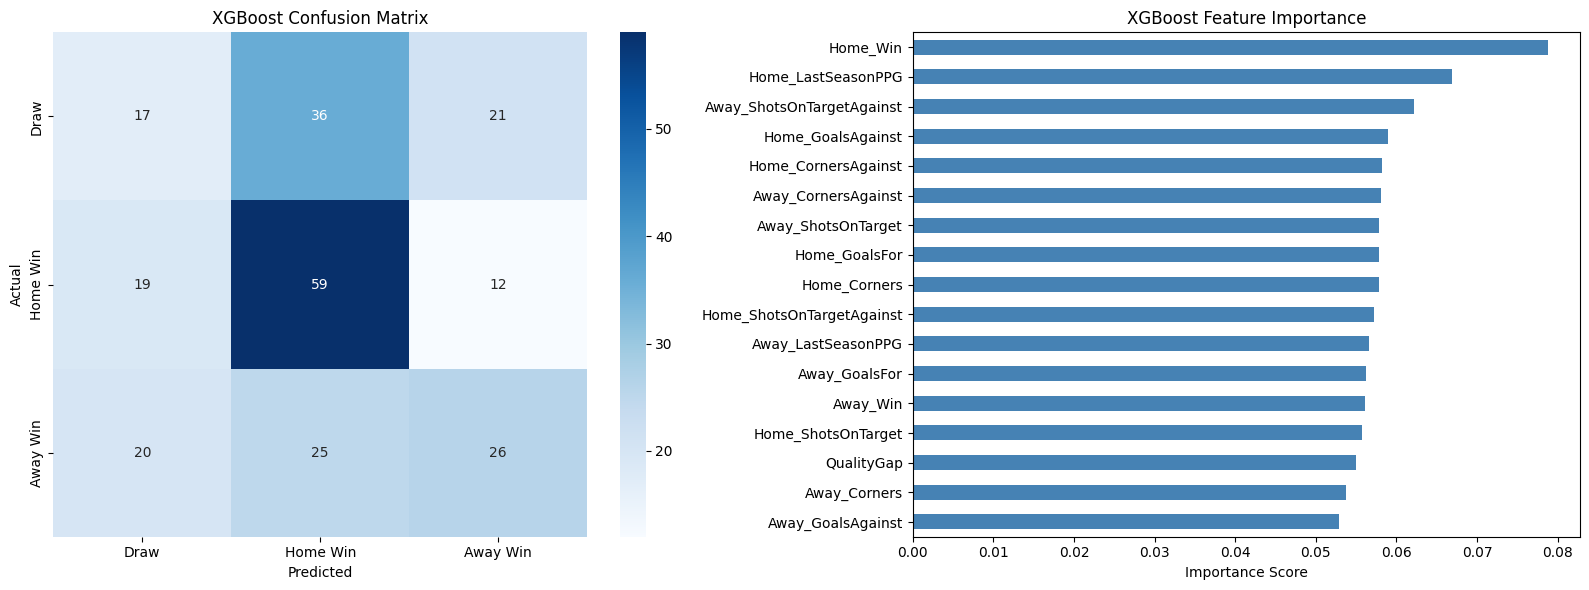

In [13]:
# ============================================================
# CELL 9: Visualize model performance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Draw", "Home Win", "Away Win"],
            yticklabels=["Draw", "Home Win", "Away Win"], ax=axes[0])
axes[0].set_title("XGBoost Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 10: Save trained model to Kaggle working directory
# ============================================================

joblib.dump(xgb_model, "/kaggle/working/model.pkl")
print("✅ Model saved to /kaggle/working/model.pkl")

✅ Model saved to /kaggle/working/model.pkl


In [15]:
# ============================================================
# CELL 11: Build features for remaining fixtures (2026-27),
# using the improved model with QualityGap + draw-weighting
# ============================================================

def build_feature_row_live(home, away, season="2026-27"):
    home_form, _ = get_team_form_with_fallback(home)
    away_form, _ = get_team_form_with_fallback(away)
    feature_row = {}
    for c in roll_cols:
        feature_row[f"Home_{c}"] = home_form[f"Roll_{c}"]
        feature_row[f"Away_{c}"] = away_form[f"Roll_{c}"]

    home_ppg = get_last_season_ppg(home, season)
    away_ppg = get_last_season_ppg(away, season)
    feature_row["Home_LastSeasonPPG"] = home_ppg
    feature_row["Away_LastSeasonPPG"] = away_ppg
    feature_row["QualityGap"] = abs(home_ppg - away_ppg)

    return pd.Series(feature_row)

fixture_features = unplayed_fixtures.apply(
    lambda r: build_feature_row_live(r["HomeTeam"], r["AwayTeam"]), axis=1
)
fixture_probs = xgb_model.predict_proba(fixture_features[FEATURE_COLS])

sim_fixtures = unplayed_fixtures[["HomeTeam", "AwayTeam"]].reset_index(drop=True).copy()
sim_fixtures["P_Draw"] = fixture_probs[:, 0]
sim_fixtures["P_HomeWin"] = fixture_probs[:, 1]
sim_fixtures["P_AwayWin"] = fixture_probs[:, 2]

print(f"Predicted probabilities for {len(sim_fixtures)} remaining fixtures:")
sim_fixtures.head(10)

Predicted probabilities for 330 remaining fixtures:


,HomeTeam,AwayTeam,P_Draw,P_HomeWin,P_AwayWin
0,Sunderland,Brighton,0.168908,0.627732,0.203359
1,Ipswich,Fulham,0.309741,0.178847,0.511412
2,Man United,Tottenham,0.299429,0.650545,0.050026
3,Aston Villa,Brentford,0.120019,0.626856,0.253126
4,Arsenal,Leeds,0.103573,0.861582,0.034844
5,Chelsea,Bournemouth,0.231983,0.584528,0.183489
6,Hull,Everton,0.311485,0.117777,0.570739
7,Liverpool,Man City,0.433750,0.262156,0.304095
8,Crystal Palace,Nott'm Forest,0.313490,0.152251,0.534258
9,Coventry,Newcastle,0.270078,0.120301,0.609622


In [ ]:
# Check what's actually inside EFL_Championship.csv
print("Date range:")
print(f"  Earliest: {champ_2025_26['Date'].min()}")
print(f"  Latest:   {champ_2025_26['Date'].max()}")
print()
print("Does it contain Hull, Coventry, or Ipswich?")
teams_in_file = pd.unique(champ_2025_26[["HomeTeam", "AwayTeam"]].values.ravel())
for team in ["Hull", "Coventry", "Ipswich"]:
    found = any(team.lower() in t.lower() for t in teams_in_file)
    print(f"  {team}: {'✅ Found' if found else '❌ Not found'}")
print()
print("All teams in this file:")
print(sorted(teams_in_file))

In [16]:
# ============================================================
# CELL 12: Calculate current standings from played matches,
# which we'll use as the starting point for the simulation
# ============================================================

def calculate_table(matches_df):
    teams = pd.unique(matches_df[["HomeTeam", "AwayTeam"]].values.ravel())
    table = pd.DataFrame({"Team": teams}).set_index("Team")
    table["Points"] = 0
    table["GD"] = 0

    for _, row in matches_df.iterrows():
        h, a, hg, ag = row["HomeTeam"], row["AwayTeam"], row["FTHG"], row["FTAG"]
        table.loc[h, "GD"] += (hg - ag)
        table.loc[a, "GD"] += (ag - hg)
        if hg > ag:
            table.loc[h, "Points"] += 3
        elif hg < ag:
            table.loc[a, "Points"] += 3
        else:
            table.loc[h, "Points"] += 1
            table.loc[a, "Points"] += 1
    return table

current_season_played = pl_2026_27[pl_2026_27["FTR"].notna()]
current_table = calculate_table(current_season_played)
current_table = current_table.sort_values(["Points", "GD"], ascending=False)
print("Current 2026-27 standings (as of today):")
current_table

Current 2026-27 standings (as of today):


,Points,GD
Team,,
Man City,15,8
Arsenal,12,4
Brighton,10,11
Brentford,9,6
Leeds,9,4
Everton,9,3
Liverpool,9,3
Hull,8,2
Newcastle,8,0


In [17]:
# ============================================================
# CELL 13: Monte Carlo simulation of the remaining season
# ============================================================

N_SIMULATIONS = 5000
all_teams = current_table.index.tolist()

finish_position_counts = {team: np.zeros(len(all_teams)) for team in all_teams}

np.random.seed(42)

for sim in range(N_SIMULATIONS):
    sim_points = current_table["Points"].to_dict()
    sim_gd = current_table["GD"].to_dict()

    for _, fixture in sim_fixtures.iterrows():
        probs = np.array([fixture["P_Draw"], fixture["P_HomeWin"], fixture["P_AwayWin"]])
        probs = probs / probs.sum()

        outcome = np.random.choice(["Draw", "Home", "Away"], p=probs)
        h, a = fixture["HomeTeam"], fixture["AwayTeam"]
        if outcome == "Home":
            sim_points[h] += 3
            sim_gd[h] += 1
            sim_gd[a] -= 1
        elif outcome == "Away":
            sim_points[a] += 3
            sim_gd[a] += 1
            sim_gd[h] -= 1
        else:
            sim_points[h] += 1
            sim_points[a] += 1

    sim_table = pd.DataFrame({
        "Team": list(sim_points.keys()),
        "Points": list(sim_points.values()),
        "GD": [sim_gd[t] for t in sim_points.keys()]
    }).sort_values(["Points", "GD"], ascending=False).reset_index(drop=True)

    for position, team in enumerate(sim_table["Team"]):
        finish_position_counts[team][position] += 1

    if (sim + 1) % 1000 == 0:
        print(f"  Completed {sim + 1}/{N_SIMULATIONS} simulations...")

print("✅ Simulation complete.")

  Completed 1000/5000 simulations...
  Completed 2000/5000 simulations...
  Completed 3000/5000 simulations...
  Completed 4000/5000 simulations...
  Completed 5000/5000 simulations...
✅ Simulation complete.


In [18]:
# ============================================================
# CELL 14: Build the final summary dataframe
# ============================================================

summary_rows = []
n_teams = len(all_teams)

for team in all_teams:
    counts = finish_position_counts[team]
    title_pct = (counts[0] / N_SIMULATIONS) * 100
    top4_pct = (counts[:4].sum() / N_SIMULATIONS) * 100
    relegation_pct = (counts[-3:].sum() / N_SIMULATIONS) * 100
    avg_finish = np.average(np.arange(1, n_teams + 1), weights=counts)

    summary_rows.append({
        "Team": team,
        "Title %": round(title_pct, 1),
        "Top 4 %": round(top4_pct, 1),
        "Relegation %": round(relegation_pct, 1),
        "Avg Finish Position": round(avg_finish, 1)
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Title %", ascending=False).reset_index(drop=True)
summary_df.index += 1

print(f"Monte Carlo Simulation Results ({N_SIMULATIONS} runs) — FINAL MODEL, 2026-27 Season")
summary_df

Monte Carlo Simulation Results (5000 runs) — FINAL MODEL, 2026-27 Season


,Team,Title %,Top 4 %,Relegation %,Avg Finish Position
1,Arsenal,81.5,100.0,0.0,1.2
2,Man City,16.7,99.2,0.0,2.2
3,Brighton,1.1,86.1,0.0,3.6
4,Man United,0.8,89.6,0.0,3.5
5,Brentford,0.0,0.0,5.6,12.6
6,Leeds,0.0,0.5,1.6,10.6
7,Liverpool,0.0,5.8,0.0,7.1
8,Everton,0.0,0.8,0.7,9.7
9,Hull,0.0,0.0,29.3,15.7
10,Newcastle,0.0,0.0,5.2,12.8


In [29]:
# ============================================================
# NEW CELL: "Day 1" simulation — predict the ENTIRE 2026-27 season
# from scratch, using only pre-season knowledge (last season's PPG +
# form as of the actual season start date), ignoring any 2026-27
# results that have actually happened so far.
# ============================================================

SEASON_START_DATE = pd.Timestamp("2026-08-21")  # actual 2026-27 kickoff date

def build_feature_row_preseason(home, away):
    """Uses form as of RIGHT BEFORE the season started — so any
    2026-27 games that have already happened are ignored entirely."""
    def form_before_season_start(team):
        history = team_log[(team_log["Team"] == team) & (team_log["Date"] < SEASON_START_DATE)]
        if len(history) == 0:
            return baseline_25th.copy()
        return history.sort_values("Date").iloc[-1][[f"Roll_{c}" for c in roll_cols]]

    home_form = form_before_season_start(home)
    away_form = form_before_season_start(away)

    feature_row = {}
    for c in roll_cols:
        feature_row[f"Home_{c}"] = home_form[f"Roll_{c}"]
        feature_row[f"Away_{c}"] = away_form[f"Roll_{c}"]

    feature_row["Home_LastSeasonPPG"] = get_last_season_ppg(home, "2026-27")
    feature_row["Away_LastSeasonPPG"] = get_last_season_ppg(away, "2026-27")

    return pd.Series(feature_row)

# Build features for ALL 380 fixtures (not just the remaining ones)
all_2026_27_fixtures = pl_2026_27[["HomeTeam", "AwayTeam"]].copy()

preseason_features = all_2026_27_fixtures.apply(
    lambda r: build_feature_row_preseason(r["HomeTeam"], r["AwayTeam"]), axis=1
)
preseason_probs = xgb_model.predict_proba(preseason_features[FEATURE_COLS])

preseason_fixtures = all_2026_27_fixtures.copy()
preseason_fixtures["P_Draw"] = preseason_probs[:, 0]
preseason_fixtures["P_HomeWin"] = preseason_probs[:, 1]
preseason_fixtures["P_AwayWin"] = preseason_probs[:, 2]

print(f"Preseason predictions built for all {len(preseason_fixtures)} matches of 2026-27.")
preseason_fixtures.head(10)

Preseason predictions built for all 380 matches of 2026-27.


,HomeTeam,AwayTeam,P_Draw,P_HomeWin,P_AwayWin
0,Arsenal,Coventry,0.151538,0.801001,0.047461
1,Hull,Man United,0.161913,0.202035,0.636053
2,Everton,Crystal Palace,0.390401,0.333800,0.275799
3,Ipswich,Sunderland,0.057075,0.156081,0.786844
4,Nott'm Forest,Leeds,0.135706,0.446906,0.417388
5,Brentford,Tottenham,0.239268,0.221312,0.539420
6,Brighton,Aston Villa,0.124227,0.753562,0.122211
7,Man City,Bournemouth,0.151649,0.715410,0.132941
8,Newcastle,Liverpool,0.307102,0.439223,0.253675
9,Fulham,Chelsea,0.207667,0.393808,0.398525


In [30]:
# ============================================================
# NEW CELL: Simulate the ENTIRE 2026-27 season from a blank slate
# (0 points for everyone), using only pre-season predictions
# ============================================================

N_SIMULATIONS = 5000
all_teams_preseason = pd.unique(all_2026_27_fixtures[["HomeTeam", "AwayTeam"]].values.ravel()).tolist()

preseason_position_counts = {team: np.zeros(len(all_teams_preseason)) for team in all_teams_preseason}

np.random.seed(42)

for sim in range(N_SIMULATIONS):
    sim_points = {team: 0 for team in all_teams_preseason}
    sim_gd = {team: 0 for team in all_teams_preseason}

    for _, fixture in preseason_fixtures.iterrows():
        probs = np.array([fixture["P_Draw"], fixture["P_HomeWin"], fixture["P_AwayWin"]])
        probs = probs / probs.sum()

        outcome = np.random.choice(["Draw", "Home", "Away"], p=probs)
        h, a = fixture["HomeTeam"], fixture["AwayTeam"]
        if outcome == "Home":
            sim_points[h] += 3
            sim_gd[h] += 1
            sim_gd[a] -= 1
        elif outcome == "Away":
            sim_points[a] += 3
            sim_gd[a] += 1
            sim_gd[h] -= 1
        else:
            sim_points[h] += 1
            sim_points[a] += 1

    sim_table = pd.DataFrame({
        "Team": list(sim_points.keys()),
        "Points": list(sim_points.values()),
        "GD": [sim_gd[t] for t in sim_points.keys()]
    }).sort_values(["Points", "GD"], ascending=False).reset_index(drop=True)

    for position, team in enumerate(sim_table["Team"]):
        preseason_position_counts[team][position] += 1

    if (sim + 1) % 1000 == 0:
        print(f"  Completed {sim + 1}/{N_SIMULATIONS} simulations...")

print("✅ Pre-season simulation complete.")

  Completed 1000/5000 simulations...
  Completed 2000/5000 simulations...
  Completed 3000/5000 simulations...
  Completed 4000/5000 simulations...
  Completed 5000/5000 simulations...
✅ Pre-season simulation complete.


In [31]:
# ============================================================
# Summarize the PRE-SEASON-ONLY simulation results
# ============================================================

preseason_summary_rows = []
n_teams_preseason = len(all_teams_preseason)

for team in all_teams_preseason:
    counts = preseason_position_counts[team]
    title_pct = (counts[0] / N_SIMULATIONS) * 100
    top4_pct = (counts[:4].sum() / N_SIMULATIONS) * 100
    relegation_pct = (counts[-3:].sum() / N_SIMULATIONS) * 100
    avg_finish = np.average(np.arange(1, n_teams_preseason + 1), weights=counts)

    preseason_summary_rows.append({
        "Team": team,
        "Title %": round(title_pct, 1),
        "Top 4 %": round(top4_pct, 1),
        "Relegation %": round(relegation_pct, 1),
        "Avg Finish Position": round(avg_finish, 1)
    })

preseason_summary_df = pd.DataFrame(preseason_summary_rows).sort_values("Title %", ascending=False).reset_index(drop=True)
preseason_summary_df.index += 1

print("Pre-season-only prediction (ignoring actual 2026-27 results so far):")
preseason_summary_df

Pre-season-only prediction (ignoring actual 2026-27 results so far):


,Team,Title %,Top 4 %,Relegation %,Avg Finish Position
1,Arsenal,46.3,96.7,0.0,1.9
2,Man City,35.1,95.4,0.0,2.1
3,Brighton,14.0,81.5,0.0,3.2
4,Bournemouth,2.9,45.2,0.0,5.1
5,Tottenham,0.9,24.8,0.1,6.4
6,Man United,0.4,22.0,0.1,6.4
7,Aston Villa,0.2,18.2,0.0,6.7
8,Liverpool,0.1,10.6,0.1,7.7
9,Hull,0.0,0.0,51.3,17.1
10,Coventry,0.0,0.0,52.1,17.1


In [ ]:
# ============================================================
# Compare simulated predictions against REAL final standings
# ============================================================

# Actual final 2025-26 table (from the real completed season)
actual_final_table = pd.DataFrame({
    "Team": ["Arsenal", "Man City", "Man United", "Aston Villa", "Liverpool",
             "Bournemouth", "Sunderland", "Brighton", "Brentford", "Chelsea",
             "Fulham", "Newcastle", "Everton", "Leeds", "Crystal Palace",
             "Nott'm Forest", "Tottenham", "West Ham", "Burnley", "Wolves"],
    "Actual_Points": [85, 78, 71, 65, 60, 57, 54, 53, 53, 52,
                       52, 49, 49, 47, 45, 44, 41, 39, 22, 20]
})
actual_final_table["Actual_Position"] = actual_final_table.index + 1

comparison = summary_df.merge(actual_final_table, on="Team")
comparison["Position_Error"] = (comparison["Avg Finish Position"] - comparison["Actual_Position"]).round(1)
comparison = comparison.sort_values("Actual_Position")

print("Predicted vs Actual — sorted by real final position:")
comparison[["Team", "Actual_Position", "Avg Finish Position", "Position_Error",
            "Title %", "Top 4 %", "Relegation %"]]

In [ ]:
# ============================================================
# CELL 15: Interactive head-to-head predictor
# ============================================================

home_dropdown = widgets.Dropdown(options=sorted(all_teams), description="Home Team:")
away_dropdown = widgets.Dropdown(options=sorted(all_teams), description="Away Team:")
predict_button = widgets.Button(description="Predict Match", button_style="success")
output_area = widgets.Output()

def on_predict_click(b):
    with output_area:
        clear_output()
        home, away = home_dropdown.value, away_dropdown.value
        if home == away:
            print("⚠️ Please select two different teams.")
            return

        home_form, home_source = get_team_form_with_fallback(home)
        away_form, away_source = get_team_form_with_fallback(away)

        feature_row = {}
        for c in roll_cols:
            feature_row[f"Home_{c}"] = home_form[f"Roll_{c}"]
            feature_row[f"Away_{c}"] = away_form[f"Roll_{c}"]
        features = pd.Series(feature_row)

        probs = xgb_model.predict_proba(features[FEATURE_COLS].values.reshape(1, -1))[0]

        print(f"{home} (Home) vs {away} (Away)\n")
        print(f"  {home} Win:  {probs[1]*100:.1f}%")
        print(f"  Draw:        {probs[0]*100:.1f}%")
        print(f"  {away} Win:  {probs[2]*100:.1f}%")

predict_button.on_click(on_predict_click)

display(widgets.HBox([home_dropdown, away_dropdown]), predict_button, output_area)